## Imports

In [1]:
%load_ext autoreload
%autoreload 2

import os
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoImageProcessor, CvtModel, CvtForImageClassification

from torchvision import models
import matplotlib.pyplot as plt

from data.datasets import DeepFakeDataset

/home/ocastaneda/anaconda3/envs/pytorch_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
image_dir_path = 'Deepfake-Eval-2024/image-data'

train_data = DeepFakeDataset("image-metadata-train.csv", image_dir_path, 'ViT', is_train = True)
train_data_loader = DataLoader(train_data, batch_size = 32, shuffle = True)

val_data = DeepFakeDataset("image-metadata-val.csv", image_dir_path, 'ViT', is_train = True)
val_data_loader = DataLoader(val_data, batch_size = 32, shuffle = True)

debug_data = DeepFakeDataset("image-metadata-debug.csv", image_dir_path, 'ViT', is_train = True)
debug_data_loader = DataLoader(debug_data, batch_size = 32, shuffle = True)

model = CvtForImageClassification.from_pretrained("microsoft/cvt-13")
# model = torch.hub.load('pytorch/vision:v0.10.0', 'resnet50', weights="ResNet50_Weights.IMAGENET1K_V1")


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0151556..2.1975338].


439


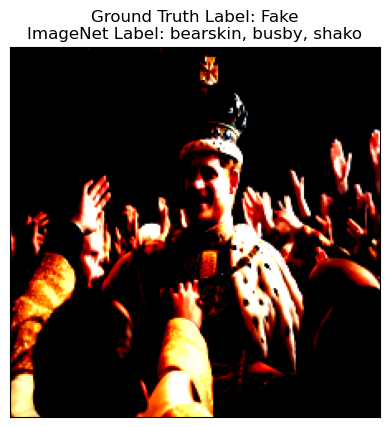

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.1461596].


439


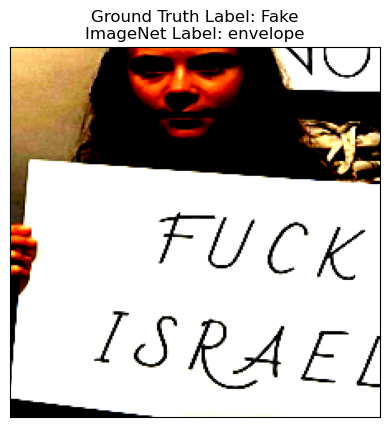

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9637812..2.235994].


439


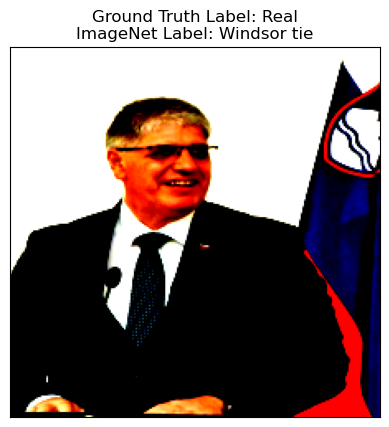

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.980906..2.2489083].


439


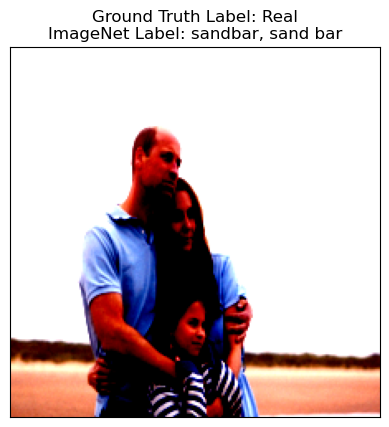

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9637812..2.465708].


439


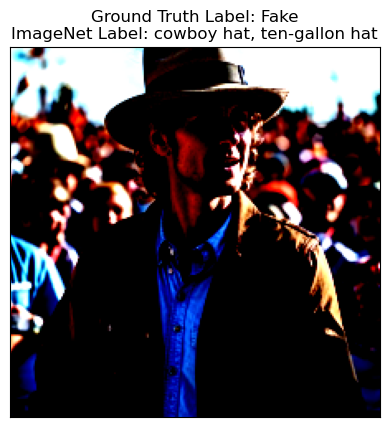

In [3]:
count = 0
features, label = next(iter(debug_data_loader))
with torch.no_grad():
    predictions = model(features).logits
    # predictions = model(features)
# print(predictions[0].argmax(-1).item())

for i in range(5):

    img = features[i]
    print(predictions[0].argmax(-1).item())
    imagenet_label = model.config.id2label[predictions[i].argmax(-1).item()]

    plt.imshow(np.transpose(img, (1,2,0))) # convert pytorch tensor (3 channels, H, W) to numpy array (H, W, 3 channels)
    plt.title(f"Ground Truth Label: {"Fake" if label[i] else "Real"}\nImageNet Label: {imagenet_label}")
    plt.xticks([])
    plt.yticks([])
    plt.show()

In [4]:
# # run this for classification models from torch.hub
# # replace classification head with passthrough effectively removing last classification layer
# model.fc = nn.Identity()    
# # extract features for train
# resnet_features = model(features)

In [ ]:
# model = CvtModel.from_pretrained("microsoft/cvt-13")
model = CvtForImageClassification.from_pretrained("microsoft/cvt-13", loss)
model.classifier = nn.Linear(384, 2, bias = True)
# model = torch.hub.load('pytorch/vision:v0.10.0', 'resnet50', weights="ResNet50_Weights.IMAGENET1K_V1")
# model.fc = nn.Linear(2048, out_features=2, bias = True)

In [6]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)
learning_rate = 1e-3
batch_size = 32
epochs = 10
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate)

In [ ]:
def train_epoch(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        outputs = model(X)
        print(outputs)
        # pred = loss_fn(pred, y)
        # loss = loss_fn(pred, y)

        # loss.backward()
        # optimizer.step()
        # optimizer.zero_grad()

        # if batch % 1 == 0:
        #     loss, current = loss.item(), batch * batch_size + len(X)
        #     print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

def test_epoch(dataloader, model, loss_fn):
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0
    
    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")


: 

In [ ]:
for t in range(epochs):
    print(f"Epoch {t+1}\n= = = = =")
    train_epoch(debug_data_loader, model, loss_fn, optimizer)
    # test_epoch(debug_data_loader, model, loss_fn, )
print("Done!")

Epoch 1
= = = = =
ImageClassifierOutputWithNoAttention(loss=None, logits=tensor([[ 0.4261,  0.1380],
        [-0.2043, -0.3504],
        [-0.3260,  0.0273],
        [-0.2704, -0.1319],
        [ 0.2785, -0.4819],
        [-0.4675, -0.1780],
        [-0.0197,  0.1406],
        [-0.1765, -0.2463],
        [ 0.1076,  0.1663],
        [-0.4119, -0.1315],
        [ 0.0121, -0.2191],
        [ 0.0200, -0.2478],
        [ 0.2862,  0.5470],
        [-0.0099,  0.0699],
        [-0.1855, -0.0919],
        [ 0.1979, -0.3705],
        [-0.3239,  0.0375],
        [-0.0099,  0.0699],
        [ 0.0705, -0.6797],
        [-0.1434,  0.1998],
        [-0.0169, -0.1711],
        [-0.1036, -0.0291],
        [-0.1036, -0.0291],
        [-0.0640,  0.0126],
        [-0.2642, -0.0540],
        [ 0.1170, -0.4859],
        [-0.2403, -0.0189],
        [ 0.4548, -0.6965],
        [ 0.2406,  0.1994],
        [-0.0737, -0.2027],
        [-0.4452,  0.2328],
        [-0.2266,  0.0092]], grad_fn=<AddmmBackward0>), hid

In [ ]:
# from torchviz import make_dot
# make_dot(model(features, return_dict = False), params = dict(model.named_parameters()))

In [ ]:
for i in model.named_modules():
    print(i)

In [ ]:
for i in model.named_modules():
    print(i)